# Welcome to Colab!

In [5]:
import numpy as np
from typing import List, Tuple, Callable
def ackley_fun(x: List[float]) -> float:
    return (-20 * np.exp(-.2*np.sqrt(.5*(x[0]**2 + x[1]**2))) -
            np.exp(.5*(np.cos(np.pi*2*x[0])+np.cos(np.pi*2*x[1]))) + np.exp(1) + 20)
def pso2D(
    fitness_fun: Callable[[float, float], float],
    data_range: Tuple[float, float],
    num_particles = 100,
    num_iterations = 50,
    c1 = 0.8,
    c2 = 0.9,
    w = 0.5,
) -> Tuple[List[List[List[float]]], List[float]]:
    # Initializing the particles and best scores
    population = np.random.uniform(
        low=data_range[0], high=data_range[1], size=(num_particles, 2))
    velocities = np.zeros((num_particles, 2))
    personal_bests = [np.inf for i in range(num_particles)]
    personal_best_solutions = np.copy(population)
    global_best = np.inf
    best_solution = population[0]
    history = [] # for animation
    global_best_fitnesses = [] # To store global best fitness at each iteration

    for i in range(num_iterations):
        history.append(np.copy(population))
        # update personal bests
        for j in range(num_particles):
            if personal_bests[j] > fitness_fun(population[j]):
                personal_bests[j] = fitness_fun(population[j])
                personal_best_solutions[j] = population[j]
        # update global best
        if min(personal_bests) < global_best:
            global_best, best_solution = \
                min(personal_bests), personal_best_solutions[np.argmin(personal_bests)]
        global_best_fitnesses.append(global_best) # Store the global best fitness
        print(f'{i}, best fitness so far: {global_best},',
              f'solution: {best_solution}')
        #update velocities and positions
        for i, (particle, v) in enumerate(zip(population, velocities)):
            v = w*v + c1*np.random.rand()*(personal_best_solutions[i] - particle) + \
                c2*np.random.rand()*(best_solution - particle)
            velocities[i] = v
            population[i] = particle + v
    return history, global_best_fitnesses
history, global_best_fitnesses = pso2D(ackley_fun, (-5, 5), num_particles=150, num_iterations=30)
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib import animation
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.array([ackley_fun([x, y]) for x, y in zip(X, Y)])
fig = plt.figure(figsize=(12, 8))
ax = mplot3d.axes3d.Axes3D(fig)
# plot the function
ax.plot_surface(X, Y, Z, rstride=2, cstride=2,
                cmap='gray', edgecolor='none')
# initialize particles (1:2 because scatter expects object with length)
data = history[0]
scatters = [
    ax.scatter(data[i, 0:1], data[i, 1:2], data[i, 2:], linewidth=9)
    for i in range(len(data))]
# Animation callback function
def animate(iteration, history, scatters):
    data = history[iteration]
    for i in range(len(data)):
        scatters[i]._offsets3d = (data[i, 0:1], data[i, 1:2], [ackley_fun(data[i])])
    return scatters
# Initial angle
ax.view_init(15, -30)
ani = animation.FuncAnimation(fig, animate, fargs=(history, scatters),
                              frames=len(history), interval=250, repeat=True, blit=False)
plt.show()

0, best fitness so far: 3.0647028683047566, solution: [0.1180531  0.84983955]
1, best fitness so far: 0.740324252780912, solution: [-0.04391201  0.11910336]
2, best fitness so far: 0.5406427793089748, solution: [0.08777495 0.05045243]
3, best fitness so far: 0.09306436841846022, solution: [ 0.02349334 -0.01200486]
4, best fitness so far: 0.07043867159281803, solution: [-0.00556812  0.02007409]
5, best fitness so far: 0.04625451637698674, solution: [ 0.00816691 -0.0118639 ]
6, best fitness so far: 0.04625451637698674, solution: [ 0.00816691 -0.0118639 ]
7, best fitness so far: 0.04625451637698674, solution: [ 0.00816691 -0.0118639 ]
8, best fitness so far: 0.02166513823121008, solution: [ 0.00487626 -0.00526368]
9, best fitness so far: 0.01650571286875646, solution: [-0.0054076   0.00123186]
10, best fitness so far: 0.004658710873989946, solution: [ 0.00078421 -0.00142019]
11, best fitness so far: 0.004387272095289774, solution: [0.00079799 0.00130439]
12, best fitness so far: 0.0042570

<Figure size 1200x800 with 0 Axes>

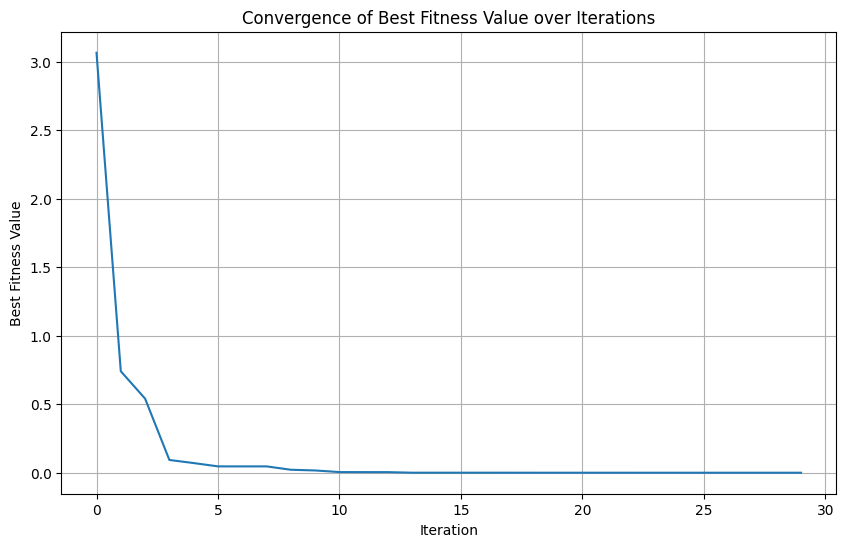

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(global_best_fitnesses)
plt.xlabel("Iteration")
plt.ylabel("Best Fitness Value")
plt.title("Convergence of Best Fitness Value over Iterations")
plt.grid(True)
plt.show()